In [111]:
import kagglehub
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("aravind3505/dengue-detection-dataset-clinical-data")

print("Path to dataset files:", path)

Path to dataset files: /home/codespace/.cache/kagglehub/datasets/aravind3505/dengue-detection-dataset-clinical-data/versions/1


In [112]:
dic = pd.read_csv("/home/codespace/.cache/kagglehub/datasets/aravind3505/dengue-detection-dataset-clinical-data/versions/1/data_dictionary.csv")

dic.head()

,Column Name,Description
0,age,Age of the patient in years
1,gender,Gender of the patient (Male/Female)
2,hemoglobin_g_dl,Hemoglobin level in grams per deciliter (g/dL)
3,wbc_count,White blood cell count (cells per microliter)
4,differential_count,Differential white blood cell count


In [113]:
import pandas as pd
df = pd.read_csv("/home/codespace/.cache/kagglehub/datasets/aravind3505/dengue-detection-dataset-clinical-data/versions/1/Dengue_diseases_dataset_modified (1).csv")
df.head()

,age,gender,hemoglobin_g_dl,wbc_count,differential_count,rbc_count,platelet_count,platelet_distribution_width,dengue_label
0,43,Male,12.6,2200.0,1,1,62000.0,11.0,1
1,45,Male,13.2,3000.0,0,1,17000.0,17.0,1
2,50,Female,11.0,3300.0,1,1,19000.0,16.3,1
3,57,Female,11.9,3500.0,1,0,29000.0,14.0,1
4,51,Female,13.0,3100.0,0,1,30000.0,14.5,1


<Axes: >

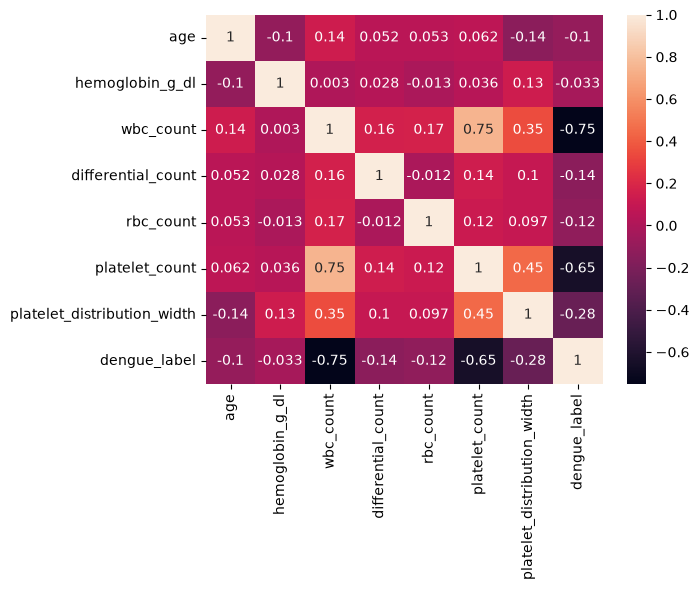

In [114]:
import seaborn as sns


sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='platelet_count', ylabel='wbc_count'>

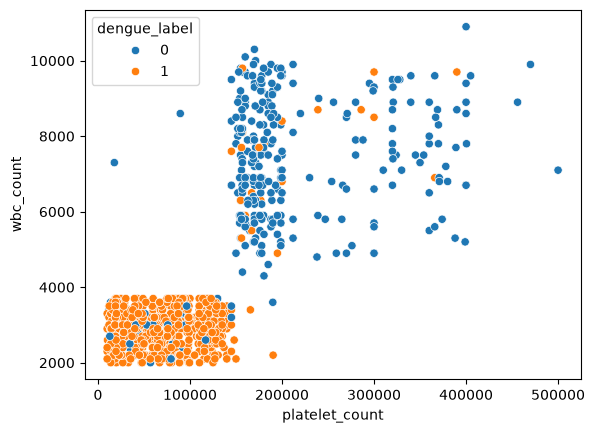

In [115]:
sns.scatterplot(data=df,x="platelet_count",y="wbc_count",hue="dengue_label")

In [116]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

In [117]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["gender"] = le.fit_transform(df['gender'])

In [118]:
df.isnull().sum()

age                             0
gender                          0
hemoglobin_g_dl                 0
wbc_count                      24
differential_count              0
rbc_count                       0
platelet_count                 16
platelet_distribution_width    19
dengue_label                    0
dtype: int64

In [119]:
def fill_null_values(column_name):
    column_mean = df[column_name].mean()
    
    # Fill the missing values inline
    df[column_name] = df[column_name].fillna(column_mean)
    
    return df
df= fill_null_values("platelet_distribution_width")
df= fill_null_values("platelet_count")
df= fill_null_values("wbc_count")

In [120]:
df.isnull().sum()

age                            0
gender                         0
hemoglobin_g_dl                0
wbc_count                      0
differential_count             0
rbc_count                      0
platelet_count                 0
platelet_distribution_width    0
dengue_label                   0
dtype: int64

In [121]:
X= df.drop("dengue_label",axis=1)
y= df["dengue_label"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [122]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [123]:
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9292929292929293


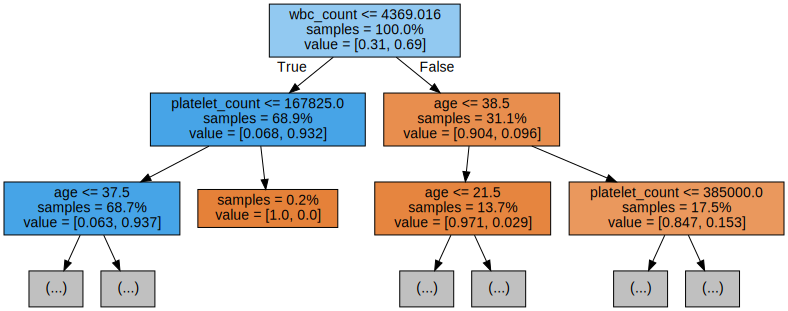

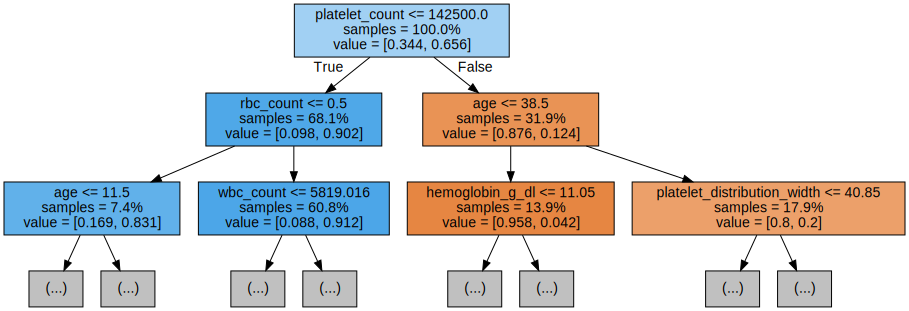

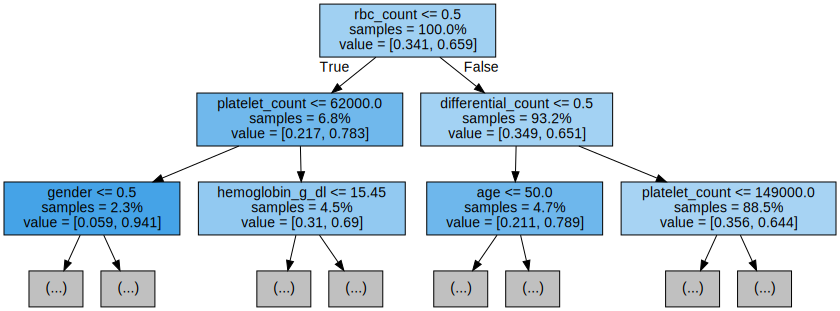

In [124]:
# Export the first three decision trees from the forest

for i in range(3):
    tree = rf.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X_train.columns,  
                               filled=True,  
                               max_depth=2, 
                               impurity=False, 
                               proportion=True)
    graph = graphviz.Source(dot_data)
    display(graph)